## Random Forest

In this part we train random forests: bagged trees where each split only considers a random subset of the inputs (`max_features`). With all the inputs available, the trees of the bagging tend to split on the same strong inputs and make correlated errors. Drawing the inputs again at each split decorrelates the trees, so that their mean has a lower variance.

### Main observations

- **Number of trees:** As for the bagging, the curves are flat from 50 trees on, and 200 trees are kept.
- **max_features:** The best values are 0.5 (yield strength, UTS) and 0.75 (elongation, Charpy). The MAE is flat between 0.33 and 1.0 (1.0 being the bagging), and goes up when too few inputs are drawn, especially on Charpy, where most splits then miss the test temperature.
- **min_samples_leaf:** Fully grown trees (1 row per leaf) are the best for every target, the mean of the trees is enough regularisation.
- **Results:** MAE of 33.9 MPa on the yield strength, 29.5 MPa on the UTS, 1.94% on the elongation and 19.1 J on the Charpy energy: 4% below the bagging on the strength targets, the same on the others. Decorrelating the trees brings little here.
- **Label:** F1 of 0.76 and recall of 0.64, below the bagging (0.81 and 0.72). The random forest predicts even fewer failures (54 on the yield strength for 102), so a lower MAE does not give a better label.

### Operations in order

1. Load the train set with `load_train`.
2. Plot the validation MAE against the number of trees, to fix `n_estimators`.
3. Tune `max_features` (share of the inputs drawn at each split) and `min_samples_leaf` (minimum number of rows in a leaf) per target by a grid search on the folds of `helpers/utils.py`.
4. Evaluate the best model of each target with `evaluate`, and compare the spread of its predictions with the measures.
5. Save it to `results.csv` and compare it with the baseline, the pruned tree and the bagging.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, validation_curve

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    SEED, TARGETS, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, evaluate, save_results,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
train = load_train()

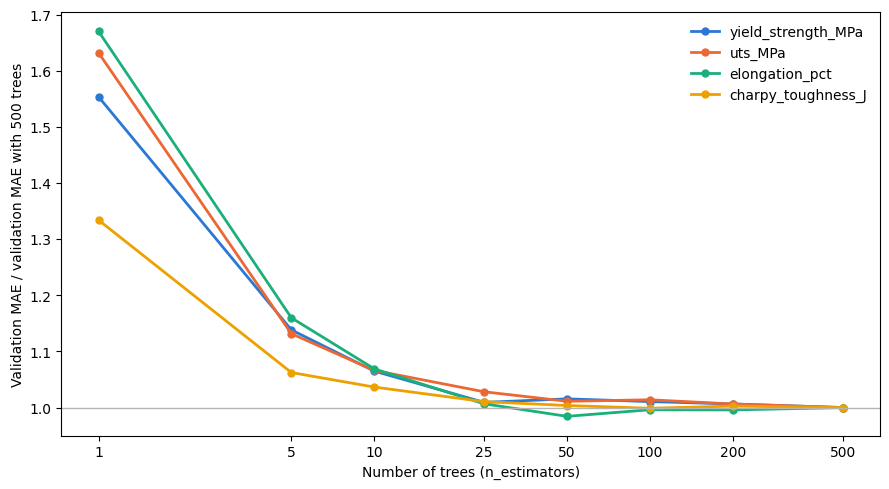

,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J
n_estimators,,,,
1,52.89,47.87,3.29,26.09
5,38.75,33.19,2.29,20.78
10,36.25,31.27,2.11,20.27
25,34.36,30.16,1.98,19.76
50,34.57,29.66,1.94,19.63
100,34.40,29.74,1.96,19.53
200,34.26,29.52,1.96,19.61
500,34.04,29.33,1.97,19.56


In [4]:
n_trees = [1, 5, 10, 25, 50, 100, 200, 500]

curves = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    _, val_scores = validation_curve(
        build_pipeline(RandomForestRegressor(max_features=0.33, random_state=SEED)),
        X, y,
        param_name="model__n_estimators",
        param_range=n_trees,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    curves[target] = -val_scores.mean(axis=1)
curves = pd.DataFrame(curves, index=pd.Index(n_trees, name="n_estimators"))

fig, ax = plt.subplots(figsize=(9, 5))
for color, target in zip(["#2a78d6", "#eb6834", "#1baf7a", "#eda100"], TARGETS):
    ax.plot(n_trees, curves[target] / curves[target].iloc[-1], color=color, linewidth=2, marker="o", markersize=5, label=target)
ax.axhline(1, color="#b5b4ae", linewidth=1)
ax.set_xscale("log")
ax.set_xticks(n_trees, n_trees)
ax.minorticks_off()
ax.set_xlabel("Number of trees (n_estimators)")
ax.set_ylabel("Validation MAE / validation MAE with 500 trees")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

curves.round(2)

Same curve as in the bagging notebook, with `max_features = 0.33`: a third of the inputs at each split, the value advised by Breiman for regression. It is only used for this curve, `max_features` is tuned below. The default of `RandomForestRegressor` is 1.0, which is the bagging.

- **1 tree:** 52.9 MPa on the yield strength, more than a single bagged tree (50.8 MPa): each split only sees 10 inputs and misses the best one more often.
- **More trees:** The curves are flat from 25 to 50 trees on, within 2% of their value at 500 trees from 50 trees on. As for the bagging, 200 trees are kept, within 1% of 500 trees on every target.

In [5]:
param_grid = {"model__max_features": [0.1, 0.2, 0.33, 0.5, 0.75, 1.0], "model__min_samples_leaf": [1, 2, 4, 8]}

searches = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    search = GridSearchCV(
        build_pipeline(RandomForestRegressor(n_estimators=200, random_state=SEED)),
        param_grid,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    search.fit(X, y)
    searches[target] = search

grid = pd.concat({
    target: pd.DataFrame(search.cv_results_).pivot(index="param_model__min_samples_leaf", columns="param_model__max_features", values="mean_test_score")
    for target, search in searches.items()
})
(-grid).rename_axis(index=["target", "min_samples_leaf"], columns="max_features").round(2)

max_features                          0.10   0.20   0.33   0.50   0.75   1.00
target             min_samples_leaf                                          
yield_strength_MPa 1                 35.93  34.33  34.26  33.90  34.56  35.09
                   2                 39.11  36.35  35.60  35.08  35.48  35.79
                   4                 43.44  39.21  38.33  37.74  37.88  38.11
                   8                 47.99  43.84  42.69  42.14  42.57  43.32
uts_MPa            1                 32.30  30.36  29.52  29.50  30.14  30.71
                   2                 35.13  32.25  30.94  30.37  30.80  31.38
                   4                 38.69  34.74  33.31  32.34  32.93  33.51
                   8                 43.63  38.85  37.33  36.72  36.83  37.49
elongation_pct     1                  2.04   2.00   1.96   1.95   1.94   1.95
                   2                  2.17   2.06   2.04   2.00   1.97   1.99
                   4                  2.37   2.20   2.15   2.10   2.08   2.08
                   8                  2.56   2.38   2.33   2.27   2.25   2.24
charpy_toughness_J 1                 20.96  20.38  19.61  19.30  19.11  19.11
                   2                 25.39  22.62  21.03  20.03  19.61  19.30
                   4                 28.46  25.03  22.88  21.65  20.85  20.37
                   8                 30.82  27.52  25.04  23.47  22.64  22.19

The validation MAE of each pair (`min_samples_leaf`, `max_features`), with 200 trees.

- **max_features = 1.0:** Every split sees every input, which is the bagging of the previous notebook: 35.1 MPa on the yield strength, against 35.2 MPa for the bagging, the gap only comes from the random draws.
- **max_features:** The MAE is flat between 0.33 and 1.0 (from 33.9 to 35.1 MPa on the yield strength), and goes up at 0.1, especially on Charpy (21.0 J against 19.1 J). With 3 inputs drawn at each split, most splits are made on inputs that explain little: on Charpy, 90% of the splits cannot use `charpy_temp_C`.
- **min_samples_leaf:** The MAE goes up with it for every `max_features`, from 33.9 to 35.1, 37.7 and 42.1 MPa on the yield strength (with `max_features = 0.5`). Fully grown trees are the best: the mean of the trees already regularises the model, and larger leaves average rows of different welds.

In [6]:
best = {target: search.best_estimator_ for target, search in searches.items()}

pd.DataFrame({
    target: {**{name.removeprefix("model__"): value for name, value in search.best_params_.items()}, "validation_MAE": -search.best_score_}
    for target, search in searches.items()
}).T

,max_features,min_samples_leaf,validation_MAE
yield_strength_MPa,0.50,1.0,33.902069
uts_MPa,0.50,1.0,29.504098
elongation_pct,0.75,1.0,1.935523
charpy_toughness_J,0.75,1.0,19.110230


`max_features` of 0.5 for the yield strength and the UTS, 0.75 for the elongation and Charpy, and fully grown trees (`min_samples_leaf = 1`) for the four targets. Compared with the bagging, the validation MAE goes down by 4% on the yield strength and the UTS (33.9 against 35.2 MPa, 29.5 against 30.8 MPa), and does not change on the elongation and Charpy.

In [7]:
forest = evaluate("Random forest", best, train)
forest.round(2)

,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc,accuracy
0,Random forest,yield_strength_MPa,all,620,33.95,47.46,3.62,6.80,619,102,0.63,0.48,0.91
1,Random forest,yield_strength_MPa,C-Mn,552,32.08,42.67,2.40,4.25,552,102,0.63,0.48,0.89
2,Random forest,yield_strength_MPa,CrMo2,30,54.21,79.78,32.89,42.94,29,0,0.00,0.00,1.00
3,Random forest,yield_strength_MPa,CrMo91,38,45.12,72.60,21.22,35.37,38,0,0.00,0.00,1.00
4,Random forest,uts_MPa,all,596,29.55,42.30,3.01,8.41,595,198,0.68,0.54,0.83
5,Random forest,uts_MPa,C-Mn,531,27.84,36.64,0.83,2.26,531,198,0.68,0.54,0.81
6,Random forest,uts_MPa,CrMo2,34,48.50,77.45,29.67,44.56,33,0,0.00,0.00,1.00
7,Random forest,uts_MPa,CrMo91,31,38.04,69.40,17.96,41.33,31,0,0.00,0.00,1.00
8,Random forest,elongation_pct,all,558,1.94,2.51,0.14,0.21,557,48,0.59,0.44,0.95
9,Random forest,elongation_pct,C-Mn,497,1.93,2.48,0.14,0.21,497,37,0.66,0.51,0.96


- **MAE:** 33.9 MPa on the yield strength, 29.5 MPa on the UTS, 1.94% on the elongation and 19.1 J on the Charpy energy, close to the bagging (35.2 MPa, 30.9 MPa, 1.95% and 19.1 J).
- **Per family:** Close to the bagging as well: 54 MPa on the yield strength of the CrMo2 welds, 45 MPa on the CrMo91 welds.
- **F1, recall per criterion:** Lower than the bagging on the yield strength (F1 of 0.63 against 0.68, recall of 0.48 against 0.57). On Charpy, the recall stays low (0.17).
- **label:** F1 of 0.76 and recall of 0.64, below the bagging (0.81 and 0.72) although the MAE is lower. A lower MAE does not guarantee a better label: the label only depends on the errors of the welds close to the thresholds.

In [8]:
preds = {target: oof_predict(best[target], train, target) for target in TARGETS}
criteria = true_criteria(train)
predicted = predicted_criteria(train, preds)

pd.DataFrame({
    "std_measured": [get_xy(train, target)[1].std() for target in TARGETS],
    "std_predicted": [preds[target]["pred"].std() for target in TARGETS],
    "non_conforming": (criteria == 0).sum(),
    "predicted_non_conforming": ((predicted == 0) & criteria.notna()).sum(),
}, index=TARGETS).round(1)

,std_measured,std_predicted,non_conforming,predicted_non_conforming
yield_strength_MPa,94.2,73.2,102,54
uts_MPa,91.9,73.5,198,119
elongation_pct,4.8,3.9,48,23
charpy_toughness_J,51.5,41.4,29,9


The same table as in the pruned CART and bagging notebooks.

- **std_predicted:** Slightly lower than for the bagging (73.2 against 76.4 MPa on the yield strength): the predictions are smoothed in the same way.
- **predicted_non_conforming:** Even fewer predicted failures than the bagging on the tensile criteria (54 against 69 on the yield strength, for 102 non-conforming rows), hence the lower recall. On Charpy, 9 rows are predicted non-conforming for 29.

In [9]:
results = save_results(forest)

models = ["Baseline (mean)", "Pruned CART", "Bagging", "Random forest"]
compared = results[results["model"].isin(models) & (results["family"] == "all")].set_index(["model", "target"])
display(compared[["MAE", "RMSE"]].unstack().reindex(index=models).reindex(columns=TARGETS, level="target").round(2))
compared[["F1_nc", "recall_nc", "accuracy"]].unstack().reindex(index=models).reindex(columns=TARGETS + ["label"], level="target").round(2)

MAE                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)              72.57   73.45           4.01              39.89   
Pruned CART                  48.24   41.78           2.60              18.87   
Bagging                      35.24   30.86           1.95              19.11   
Random forest                33.95   29.55           1.94              19.09   

                              RMSE                                            
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J  
model                                                                         
Baseline (mean)              94.41   92.19           4.85              51.73  
Pruned CART                  66.22   59.97           3.32              32.46  
Bagging                      49.40   44.45           2.51              28.16  
Random forest                47.46   42.30           2.51              28.39

F1_nc                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)               0.00    0.00           0.00               0.00   
Pruned CART                   0.60    0.64           0.46               0.52   
Bagging                       0.68    0.67           0.62               0.17   
Random forest                 0.63    0.68           0.59               0.26   

                               recall_nc                         \
target          label yield_strength_MPa uts_MPa elongation_pct   
model                                                             
Baseline (mean)  0.00               0.00    0.00           0.00   
Pruned CART      0.77               0.60    0.63           0.50   
Bagging          0.81               0.57    0.56           0.50   
Random forest    0.76               0.48    0.54           0.44   

                                                   accuracy          \
target          charpy_toughness_J label yield_strength_MPa uts_MPa   
model                                                                 
Baseline (mean)               0.00  0.00               0.84    0.67   
Pruned CART                   0.62  0.81               0.87    0.76   
Bagging                       0.10  0.72               0.91    0.82   
Random forest                 0.17  0.64               0.91    0.83   

                                                         
target          elongation_pct charpy_toughness_J label  
model                                                    
Baseline (mean)           0.91               0.91  0.53  
Pruned CART               0.90               0.90  0.77  
Bagging                   0.95               0.91  0.84  
Random forest             0.95               0.91  0.81

The random forest is slightly better than the bagging on the MAE of the yield strength and the UTS, the same on the elongation and Charpy, and worse on the F1 and the recall of the label.